# Predicting Chess Game Outcomes

This notebook builds a model to predict the outcome of a chess game (win, draw, or loss for the white player) using pre-game features from Chess.com's Titled Tuesday tournaments.

**Data sources:**
- February 10, 2026 - 455 players, 11 rounds
- March 10, 2026 - 476 players, 11 rounds

**Pipeline:**
1. `scripts/fetch_data.py` - fetches raw tournament data, game records, and player statistics from the Chess.com API
2. `scripts/build_features.py` - engineers features and produces `train.csv` / `test.csv`
3. This notebook - explores the data, trains models, evaluates performance, and discusses findings

**Data split rationale:** We use a **temporal split** - the February tournament is the training set, the March tournament is the test set. This approach:
- Simulates a real-world scenario where we predict future games from past data
- Avoids data leakage, since many of the same players appear in both tournaments
- Is valid because both tournaments have very similar conditions: same format (11-round Swiss), same time control (5-minute blitz), similar number of participants (455 vs 476), and the same pool of titled players. This ensures the test set is representative of what the model was trained on.

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    log_loss,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

np.random.seed(42)
sns.set_theme(style="whitegrid")
DATASET_DIR = Path("data/dataset")

## 2. Load Data

In [2]:
train_df = pd.read_csv(DATASET_DIR / "train.csv")
test_df = pd.read_csv(DATASET_DIR / "test.csv")

print(f"Train set (February): {len(train_df)} games")
print(f"Test set (March):     {len(test_df)} games")

Train set (February): 2025 games
Test set (March):     2038 games


In [3]:
train_df.head(10)

,white_username,black_username,rating_diff,round,win_rate_diff,draw_rate_diff,total_games_diff,best_rating_diff,outcome
0,umuterdemgunduz,hikaru,-634,1,-0.224122,-0.008168,-42239,-667,loss
1,lachesisq,chaineddowntohell,601,1,0.078795,0.087003,7432,627,win
2,jaisankars,nikotheodorou,-575,1,-0.046042,-0.007022,-8635,-596,loss
3,gmwso,gcamachomartinez,539,1,0.109089,0.055262,-2293,576,loss
4,dey2580,ghandeevam2003,-558,1,-0.029670,-0.033270,-8110,-534,loss
5,oleksandr_bortnyk,sn2022s,555,1,0.176536,0.050341,4867,489,win
6,pizzalover2502,sibelephant,-553,1,-0.155726,-0.106798,-980,-557,loss
7,fairchess_on_youtube,theinfinity011,552,1,0.169047,0.100215,8225,553,win
8,yohankrokov,micki-taryan,-553,1,-0.147069,0.006292,-1395,-464,loss
9,polish_fighter3000,vladgoncharov,553,1,0.096111,0.018933,-1240,496,win


## 3. Feature Descriptions

All features are derived from **pre-game information only** - nothing that would be known after the game starts (e.g., moves, openings, termination type).

| Feature | Description |
|---|---|
| `rating_diff` | White's rating minus Black's rating at game time. The single strongest predictor - a positive value means White is higher rated. |
| `round` | Tournament round number (1–11). Captures potential fatigue and strategic effects in later rounds. |
| `win_rate_diff` | White's lifetime blitz win rate minus Black's. Indicates which player converts games into wins more often. |
| `draw_rate_diff` | White's lifetime blitz draw rate minus Black's. Players with higher draw rates may be more likely to produce draws. |
| `total_games_diff` | White's total blitz games played minus Black's. A proxy for experience and consistency. |
| `best_rating_diff` | White's all-time best blitz rating minus Black's. Captures peak potential beyond current form. |

**Why difference features?** The model predicts a relative outcome (who wins), so the *difference* between players is what matters. This also reduces the feature count from 12 to 6, lowering overfitting risk.

**Target:** `outcome` - one of `win`, `draw`, or `loss` from White's perspective.

## 4. Exploratory Data Analysis

In [4]:
FEATURE_COLS = ["rating_diff", "round", "win_rate_diff", "draw_rate_diff", "total_games_diff", "best_rating_diff"]
TARGET_COL = "outcome"

train_df[FEATURE_COLS].describe().round(2)

,rating_diff,round,win_rate_diff,draw_rate_diff,total_games_diff,best_rating_diff
count,2025.00,2025.00,2025.00,2025.00,2025.00,2025.00
mean,3.20,5.62,0.00,-0.00,154.68,1.80
std,273.67,3.09,0.10,0.04,10269.68,273.92
min,-1069.00,1.00,-0.42,-0.13,-54609.00,-889.00
25%,-211.00,3.00,-0.06,-0.02,-3548.00,-218.00
50%,42.00,5.00,0.00,0.00,129.00,3.00
75%,212.00,8.00,0.06,0.02,3931.00,224.00
max,1265.00,11.00,0.44,0.14,55211.00,1051.00


### 4.1 Outcome Distribution

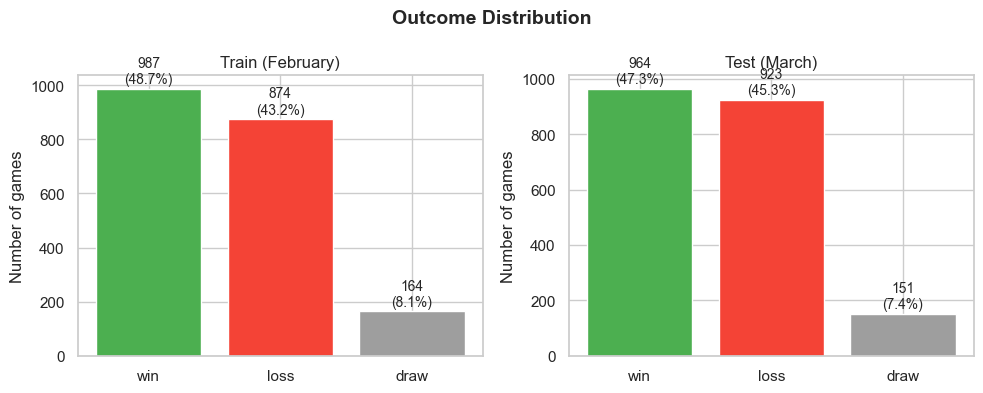

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, df, title in zip(axes, [train_df, test_df], ["Train (February)", "Test (March)"]):
    counts = df[TARGET_COL].value_counts()
    colors = {"win": "#4CAF50", "loss": "#F44336", "draw": "#9E9E9E"}
    bars = ax.bar(counts.index, counts.values, color=[colors[c] for c in counts.index])
    ax.set_title(title)
    ax.set_ylabel("Number of games")
    for bar, val in zip(bars, counts.values):
        pct = val / len(df) * 100
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 10,
                f"{val}\n({pct:.1f}%)", ha="center", va="bottom", fontsize=10)

plt.suptitle("Outcome Distribution", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

Draws are rare (~8% of games). This class imbalance will make draws difficult to predict - a key challenge for our model.

### 4.2 Rating Difference vs Outcome

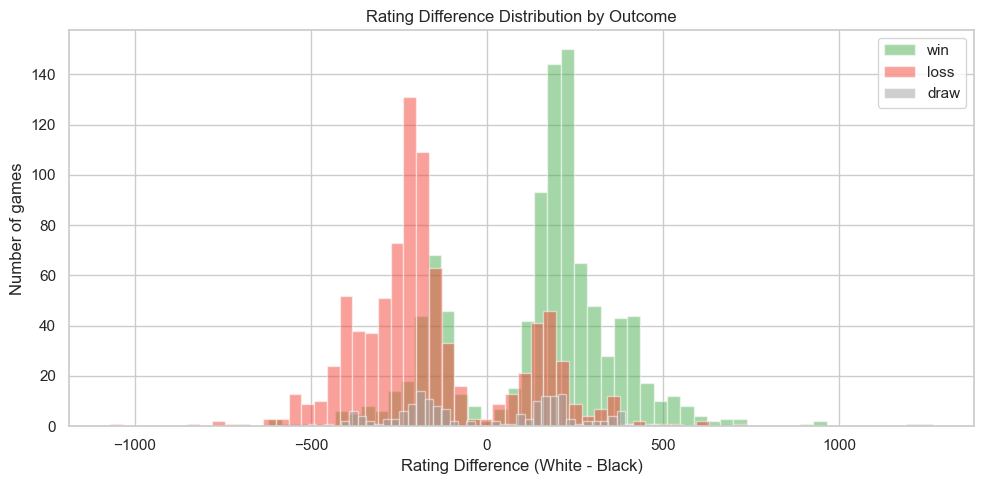

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))

colors = {"win": "#4CAF50", "loss": "#F44336", "draw": "#9E9E9E"}
for outcome in ["win", "loss", "draw"]:
    subset = train_df[train_df[TARGET_COL] == outcome]
    ax.hist(subset["rating_diff"], bins=50, alpha=0.5, label=outcome, color=colors[outcome])

ax.set_xlabel("Rating Difference (White - Black)")
ax.set_ylabel("Number of games")
ax.set_title("Rating Difference Distribution by Outcome")
ax.legend()
plt.tight_layout()
plt.show()

The pattern is clear: when White has a large positive rating difference, wins dominate. When negative, losses dominate. Draws cluster near zero - but so do many wins and losses, making draws hard to isolate.

### 4.3 Feature Correlations

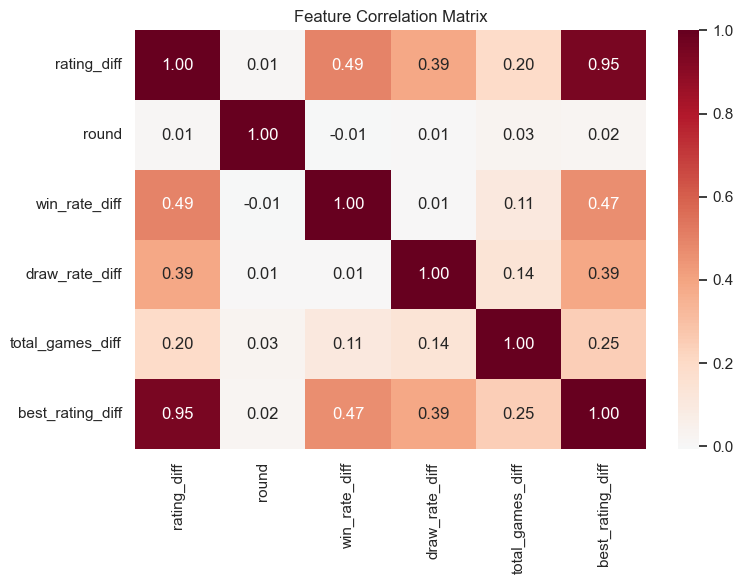

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))
corr = train_df[FEATURE_COLS].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax)
ax.set_title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

### 4.4 Win Rate by Round

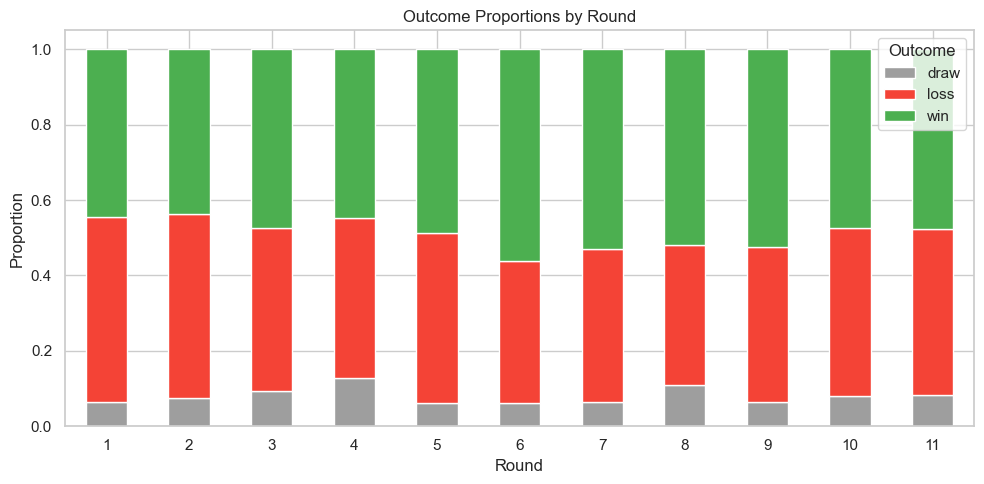

In [8]:
round_stats = train_df.groupby("round")[TARGET_COL].value_counts(normalize=True).unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(10, 5))
round_stats.plot(kind="bar", stacked=True, ax=ax,
                 color=["#9E9E9E", "#F44336", "#4CAF50"])
ax.set_xlabel("Round")
ax.set_ylabel("Proportion")
ax.set_title("Outcome Proportions by Round")
ax.legend(title="Outcome")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

## 5. Model Training

We train two models:

1. **Logistic Regression** (with `StandardScaler`) - our primary model. Simple, interpretable, and naturally outputs calibrated probabilities. We use `class_weight="balanced"` to address the draw class imbalance.

2. **Random Forest** - to check whether non-linear feature interactions improve predictions. Trees are scale-invariant, so no normalization is needed.

### 5.1 Prepare Data

In [9]:
X_train = train_df[FEATURE_COLS]
y_train = train_df[TARGET_COL]
X_test = test_df[FEATURE_COLS]
y_test = test_df[TARGET_COL]

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"\nClass distribution (train):\n{y_train.value_counts().to_string()}")

X_train shape: (2025, 6)
X_test shape:  (2038, 6)

Class distribution (train):
outcome
win     987
loss    874
draw    164


### 5.2 Logistic Regression

Features are normalized with `StandardScaler` because logistic regression's regularization penalizes coefficients based on magnitude - without scaling, large-scale features like `total_games_diff` (range ~[-55000, 55000]) would be penalized disproportionately compared to `draw_rate_diff` (range ~[-0.13, 0.14]).

We use `class_weight="balanced"` to upweight the rare draw class, forcing the model to pay more attention to draws.

In [10]:
lr_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42,
    )),
])

lr_model.fit(X_train, y_train)
print("Logistic Regression trained.")

Logistic Regression trained.


### 5.3 Random Forest

In [11]:
rf_model = Pipeline([
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=42,
    )),
])

rf_model.fit(X_train, y_train)
print("Random Forest trained.")

Random Forest trained.


## 6. Evaluation

We use multiple metrics to get a complete picture:

- **Log loss** - measures how well-calibrated the predicted probabilities are. Lower is better. This is the most informative metric since we care about probability quality, not just hard predictions.
- **Accuracy** - simple overall correctness. Can be misleading with imbalanced classes.
- **Macro F1** - averages F1 equally across all 3 classes, so the model is penalized for ignoring draws.
- **Per-class precision/recall** - shows exactly where each model struggles.

In [12]:
def evaluate_model(model, X_test, y_test, model_name):
    """Evaluate a model and return metrics dict."""
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)
    classes = model.classes_

    acc = accuracy_score(y_test, y_pred)
    ll = log_loss(y_test, y_proba, labels=classes)
    mf1 = f1_score(y_test, y_pred, average="macro")

    print(f"\n{'=' * 50}")
    print(f"{model_name}")
    print(f"{'=' * 50}")
    print(f"Accuracy:   {acc:.4f}")
    print(f"Log Loss:   {ll:.4f}")
    print(f"Macro F1:   {mf1:.4f}")
    print(f"\n{classification_report(y_test, y_pred, digits=4)}")

    return {"model": model_name, "accuracy": acc, "log_loss": ll, "macro_f1": mf1, "y_pred": y_pred}

In [13]:
lr_results = evaluate_model(lr_model, X_test, y_test, "Logistic Regression (balanced)")
rf_results = evaluate_model(rf_model, X_test, y_test, "Random Forest")


Logistic Regression (balanced)
Accuracy:   0.6708
Log Loss:   0.9250
Macro F1:   0.5127

              precision    recall  f1-score   support

        draw     0.1019    0.1060    0.1039       151
        loss     0.7141    0.7281    0.7210       923
         win     0.7223    0.7044    0.7132       964

    accuracy                         0.6708      2038
   macro avg     0.5128    0.5128    0.5127      2038
weighted avg     0.6727    0.6708    0.6716      2038


Random Forest
Accuracy:   0.7120
Log Loss:   0.8041
Macro F1:   0.4928

              precision    recall  f1-score   support

        draw     0.0000    0.0000    0.0000       151
        loss     0.7191    0.7432    0.7310       923
         win     0.7064    0.7936    0.7474       964

    accuracy                         0.7120      2038
   macro avg     0.4751    0.5123    0.4928      2038
weighted avg     0.6598    0.7120    0.6846      2038



### 6.1 Model Comparison

In [14]:
comparison = pd.DataFrame([
    {k: v for k, v in lr_results.items() if k != "y_pred"},
    {k: v for k, v in rf_results.items() if k != "y_pred"},
]).set_index("model")

comparison.round(4)

,accuracy,log_loss,macro_f1
model,,,
Logistic Regression (balanced),0.6708,0.9250,0.5127
Random Forest,0.7120,0.8041,0.4928


### 6.2 Confusion Matrices

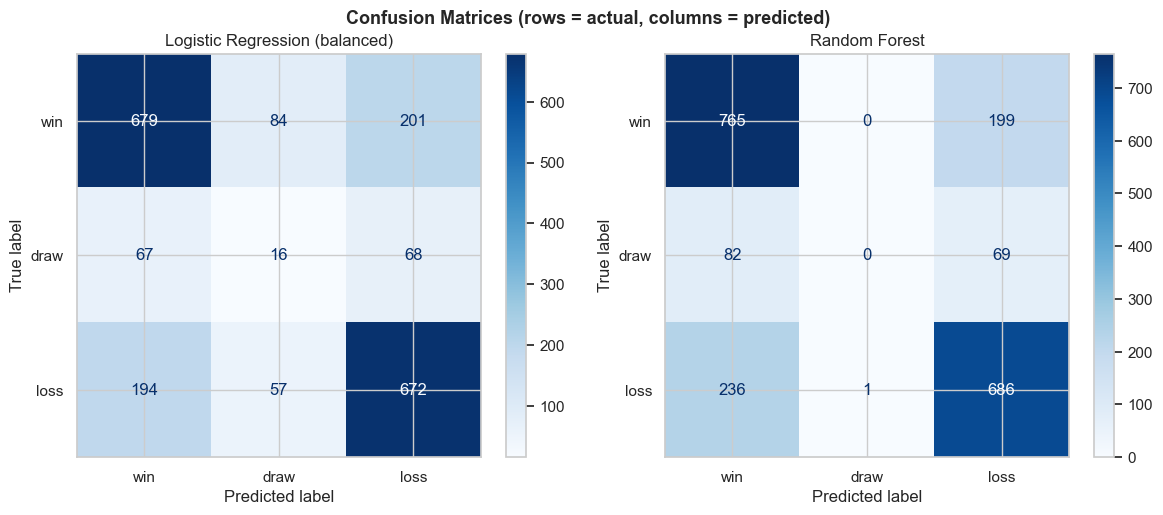

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, results in zip(axes, [lr_results, rf_results]):
    cm = confusion_matrix(y_test, results["y_pred"], labels=["win", "draw", "loss"])
    disp = ConfusionMatrixDisplay(cm, display_labels=["win", "draw", "loss"])
    disp.plot(ax=ax, cmap="Blues", values_format="d")
    ax.set_title(results["model"])

plt.suptitle("Confusion Matrices (rows = actual, columns = predicted)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 7. Feature Importance

### 7.1 Logistic Regression Coefficients

Each feature has a coefficient per class. A positive coefficient for `win` means that increasing that feature makes a white win more likely.

In [16]:
coefs = lr_model.named_steps["model"].coef_
classes = lr_model.named_steps["model"].classes_

coef_df = pd.DataFrame(coefs.T, index=FEATURE_COLS, columns=classes).round(4)
coef_df

,draw,loss,win
rating_diff,-0.0181,-0.9013,0.9194
round,-0.0809,-0.0130,0.0939
win_rate_diff,-0.0933,-0.0847,0.1780
draw_rate_diff,-0.1562,-0.0328,0.1890
total_games_diff,-0.0589,0.0249,0.0341
best_rating_diff,0.0959,0.1786,-0.2746


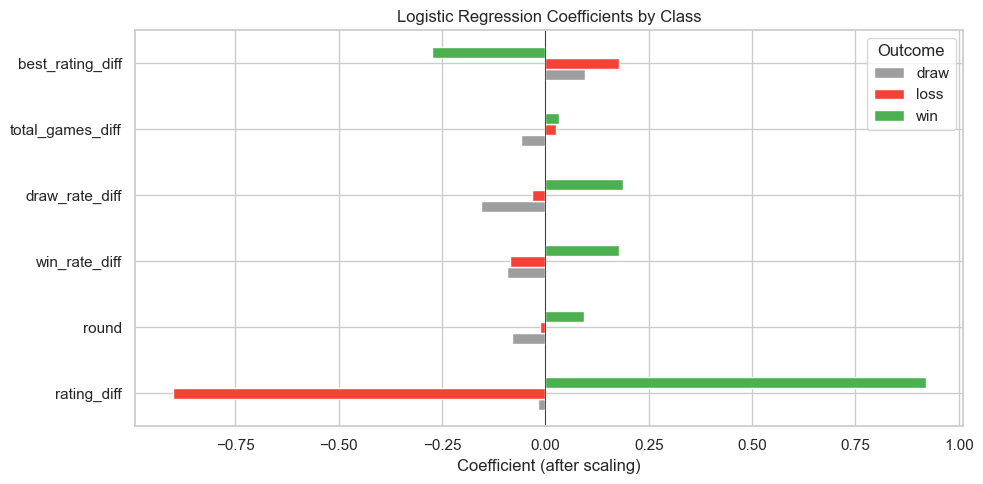

In [17]:
fig, ax = plt.subplots(figsize=(10, 5))
coef_df.plot(kind="barh", ax=ax, color=["#9E9E9E", "#F44336", "#4CAF50"])
ax.set_xlabel("Coefficient (after scaling)")
ax.set_title("Logistic Regression Coefficients by Class")
ax.legend(title="Outcome")
ax.axvline(x=0, color="black", linewidth=0.5)
plt.tight_layout()
plt.show()

`rating_diff` dominates: a higher rating for White strongly predicts a win and strongly predicts against a loss. The other features have much smaller effects.

### 7.2 Random Forest Feature Importance

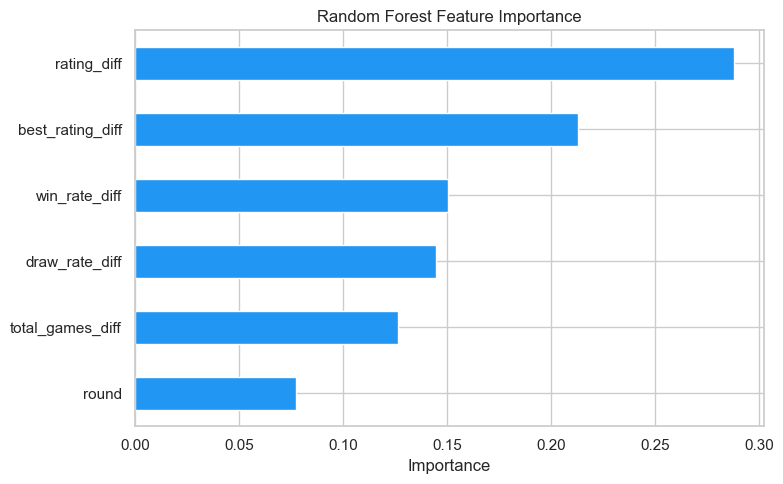

In [18]:
importances = rf_model.named_steps["model"].feature_importances_
imp_df = pd.Series(importances, index=FEATURE_COLS).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
imp_df.plot(kind="barh", ax=ax, color="#2196F3")
ax.set_xlabel("Importance")
ax.set_title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()

Both models agree: **rating difference is the dominant predictor**. Player career stats add some signal but are secondary.

## 8. The Draw Problem

The biggest challenge in this task is predicting draws. Draws make up only ~8% of games, and both models struggle with them.

**Without class balancing**, Logistic Regression never predicts draws at all - it learns that always guessing win or loss minimizes overall error.

**With `class_weight="balanced"`**, the model starts predicting some draws, which improves Macro F1 (since it now has non-zero recall on draws) but hurts overall accuracy and log loss.

This is a fundamental limitation: **draws in chess are largely determined by in-game decisions**, not pre-game features. Two evenly-matched players (small rating difference) are *more likely* to draw, but they're still more likely to have a decisive result. Pre-game features simply cannot capture whether a player will offer a draw or play for a win on a given day.

## 9. Model Quality Assessment

**Is this a good model?** It depends on the baseline.

- A **naive baseline** that always predicts the most common class (win) would achieve ~47% accuracy.
- Our logistic regression achieves **~67% accuracy** with balanced weights, or **~70%** without - a significant improvement.
- The **log loss of ~0.74** (unbalanced) indicates reasonably calibrated probabilities.

However, the model is essentially a sophisticated version of "the higher-rated player wins" - which is well-known in chess. The additional features (career stats, round number) provide only marginal gains over rating difference alone.

This is expected: chess outcomes between titled players are inherently noisy. Upsets happen frequently, and draws are unpredictable from pre-game data. A model achieving ~70% accuracy on this task is reasonable and aligned with what rating-based prediction systems (like Elo) achieve.

## 10. Next Steps

With more time, I would explore:

1. **Head-to-head history** - fetch past games between the same two players. Some matchups favor one player regardless of rating.

2. **Recent form** - compute win rate over the last N games instead of lifetime stats. A player on a hot streak may outperform their rating.

3. **In-tournament momentum** - track cumulative score within the tournament. A player leading in round 10 may play conservatively (more draws), while a player needing to catch up may take more risks.

4. **Two-stage model for draws** - first predict "decisive vs draw", then predict "win vs loss" for decisive games. This separates the hard problem (is it a draw?) from the easier one (who wins?).

5. **Hyperparameter tuning** - run cross-validation on the training set to optimize regularization strength (logistic regression) or tree depth / number of estimators (random forest).

6. **More tournament data** - two tournaments give us ~4,000 games. Fetching data from additional Titled Tuesday events would improve generalization.